# short task description

1. **model:**  Image + Text → Text
2. **dataset:**
 - training:
    - linxy/LaTeX_OCR
    - deepcopy/MathWriting-human
 - evaluation:
    - linxy/LaTeX_OCR  test subset (70 examples) 
3. choose metrics
4. compare 
    1. Zero-shot inference 
    2. One-shot inference 
    3. Supervised fine-tuning (SFT) using linxy/LaTeX_OCR:train 
    4. SFT using linxy/LaTeX_OCR:train + deepcopy/MathWriting-huma

# libs 

In [101]:
import sys
print(f"Python: {sys.version}")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


**requirements:**





In [102]:
!pip show torch transformers

Name: torch
Version: 2.10.0+cu128
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /usr/local/lib/python3.12/dist-packages
Requires: cuda-bindings, filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-cufile-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvshmem-cu12, nvidia-nvtx-cu12, setuptools, sympy, triton, typing-extensions
Required-by: accelerate, bitsandbytes, cut-cross-entropy, easyocr, fastai, kornia, peft, pytorch-ignite, pytorch-lightning, sentence-transformers, timm, torchaudio, torchdata, torchmetrics, torchvision, unsloth, unsloth_zoo, xformers
---
Name: transformers
Version: 5.5.0
Summary: Transformers:

In [103]:
!pip install unsloth>=2025.2.0

In [104]:
!pip show torch transformers unsloth

Name: torch
Version: 2.10.0+cu128
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /usr/local/lib/python3.12/dist-packages
Requires: cuda-bindings, filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-cufile-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvshmem-cu12, nvidia-nvtx-cu12, setuptools, sympy, triton, typing-extensions
Required-by: accelerate, bitsandbytes, cut-cross-entropy, easyocr, fastai, kornia, peft, pytorch-ignite, pytorch-lightning, sentence-transformers, timm, torchaudio, torchdata, torchmetrics, torchvision, unsloth, unsloth_zoo, xformers
---
Name: transformers
Version: 5.5.0
Summary: Transformers:

In [105]:
!pip show numpy

Name: numpy
Version: 2.4.6
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: 
Required-by: accelerate, access, albucore, albumentations, ale-py, arviz, astropy, autograd, bayesian-optimization, bigframes, bitsandbytes, blis, blosc2, bokeh, Boruta, Bottleneck, bqplot, Cartopy, catboost, category_encoders, cesium, chex, clarabel, cmdstanpy, ConfigSpace, contourpy, cucim-cu12, cuda-core, cudf-cu12, cufflinks, cuml-cu12, cupy-cuda12x, cuvs-cu12, cvxpy, cyipopt, dask-cuda, dask-cudf-cu12, datasets, db-dtypes, deap, diffusers, dipy, dm-tree, dopamine_rl, easyocr, esda, fasttext, featuretools, flax, folium, fury, geemap, gensim, geopandas, gradio, grain, gym, gymnasium, h5netcdf, h5py, hdbscan, hep_ml, highspy, holoviews, hyperopt, ImageHash, ImageIO, imbalanced-learn, inequality, ipympl, jax, jaxlib, kaggle-environments, keras, keras-cor

In [ ]:
import os
import re
import math
from PIL import Image
import subprocess
from tqdm import tqdm
from typing import List, Dict, Union, Optional
from IPython.display import display

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.cuda import is_bf16_supported

from datasets import DatasetDict, load_dataset, Dataset
from huggingface_hub import hf_hub_download, list_repo_files

from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator

from transformers import (
    AutoModel, 
    AutoProcessor, 
    Trainer, 
    TrainingArguments,
    GPT2TokenizerFast, 
    GPT2Model
)
from trl import SFTTrainer, SFTConfig
from peft import LoraConfig, get_peft_model, TaskType

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import editdistance

import torch._dynamo
torch._dynamo.config.disable = True

# hardware

In [107]:
!nvcc --version 

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [ ]:
def get_training_precision():
    if not torch.cuda.is_available():
        return {"fp16": False, "bf16": False, "use_cpu": True, "no_cuda": True}
    
    gpu_capability = torch.cuda.get_device_capability(0)
    
    if gpu_capability[0] >= 8:
        return {"fp16": False, "bf16": True, "use_cpu": False, "no_cuda": False}
    else:
        return {"fp16": True, "bf16": False, "use_cpu": False, "no_cuda": False}

get_training_precision()

{'fp16': True, 'bf16': False, 'use_cpu': False, 'no_cuda': False}

In [109]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')  
num_gpus = torch.cuda.device_count()
print(f"CUDA версия: {torch.version.cuda}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"device={device}, num_gpus={num_gpus}")
print(f"BFloat16 support: {is_bf16_supported()}")

CUDA версия: 12.8
GPU: Tesla T4
VRAM: 15.6 GB
device=cuda, num_gpus=2
BFloat16 support: False


# params

In [ ]:
MODEL_ID = "unsloth/Qwen3-VL-2B-Instruct-unsloth-bnb-4bit"
DATASET_IDs = ["linxy/LaTeX_OCR", "deepcopy/MathWriting-human"]

MAX_LENGTH = 2048  
MAX_PIXELS = 262144  

# model

In [111]:
model, processor = FastVisionModel.from_pretrained(
    MODEL_ID,
    load_in_4bit=True,
    max_seq_length=MAX_LENGTH,
    dtype=torch.float16,
    device_map = "auto",
    use_gradient_checkpointing = "unsloth"
)

==((====))==  Unsloth 2026.6.1: Fast Qwen3_Vl patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

# data

## dataset linxy

In [112]:
dataset_linxy = load_dataset(DATASET_IDs[0], name="human_handwrite")

In [113]:
dataset_linxy

DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 1200
    })
    validation: Dataset({
        features: ['image', 'text'],
        num_rows: 68
    })
    test: Dataset({
        features: ['image', 'text'],
        num_rows: 70
    })
})

In [114]:
dataset_linxy = dataset_linxy.rename_column("text", "latex")

In [ ]:
dataset_linxy

DatasetDict({
    train: Dataset({
        features: ['image', 'latex'],
        num_rows: 1200
    })
    validation: Dataset({
        features: ['image', 'latex'],
        num_rows: 68
    })
    test: Dataset({
        features: ['image', 'latex'],
        num_rows: 70
    })
})

In [ ]:
dataset_linxy

In [ ]:
len(set(x['latex'] for x in dataset_linxy['train'])), len(set(x['latex'] for x in dataset_linxy['validation'])), len(set(x['latex'] for x in dataset_linxy['test']))

(292, 26, 23)

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=515x213 at 0x79039E615C10>, 'latex': '\\sqrt { b ^ { 2 } - 4 a c }'}


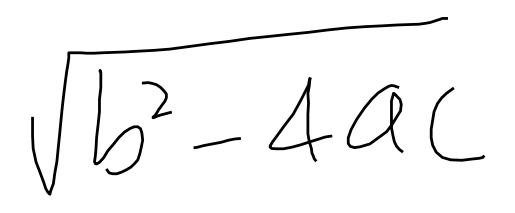

In [116]:
print(dataset_linxy['test'][0])
dataset_linxy['test'][0]['image']

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=515x111 at 0x7903F4501A60>, 'latex': '\\sqrt { x - y - z + x ^ { 2 } + y ^ { 2 } + z ^ { 2 } }'}


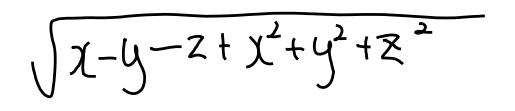

In [117]:
print(dataset_linxy['test'][1])
dataset_linxy['test'][1]['image']

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=515x232 at 0x79039E18A9F0>, 'latex': '\\frac { 2 \\tan \\alpha } { 1 - \\tan ^ { 2 } \\alpha }'}


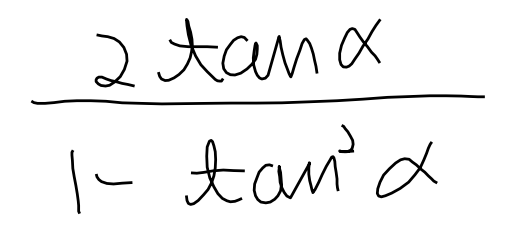

In [118]:
print(dataset_linxy['test'][2])
dataset_linxy['test'][2]['image']

## dataset deepcopy

In [119]:
dataset_deepcopy = load_dataset(DATASET_IDs[1], 
                                split=['train[:5%]', 'val[:5%]', 'test[:5%]'])
dataset_deepcopy = DatasetDict({
    'train': dataset_deepcopy[0],
    'val': dataset_deepcopy[1],
    'test': dataset_deepcopy[2]
})

In [120]:
dataset_deepcopy

DatasetDict({
    train: Dataset({
        features: ['image', 'latex', 'sample_id', 'split_tag', 'data_type'],
        num_rows: 11493
    })
    val: Dataset({
        features: ['image', 'latex', 'sample_id', 'split_tag', 'data_type'],
        num_rows: 784
    })
    test: Dataset({
        features: ['image', 'latex', 'sample_id', 'split_tag', 'data_type'],
        num_rows: 382
    })
})

In [ ]:
len(set(x['latex'] for x in dataset_deepcopy['train'])), len(set(x['latex'] for x in dataset_deepcopy['val'])), len(set(x['latex'] for x in dataset_deepcopy['test']))

(8151, 745, 370)

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=324x115 at 0x79039DE40EC0>, 'latex': '\\overline{X}+X_{\\xi}', 'sample_id': '7fa5c261545ac47c', 'split_tag': 'test', 'data_type': 'human'}


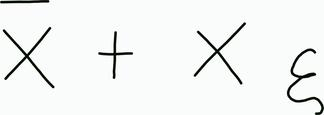

In [121]:
print(dataset_deepcopy['test'][0])
dataset_deepcopy['test'][0]['image']

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=467x117 at 0x79039DE42FF0>, 'latex': '\\frac{q}{A}=h_{o}(T_{o}-T_{s})', 'sample_id': '90320c048bb19cfb', 'split_tag': 'test', 'data_type': 'human'}


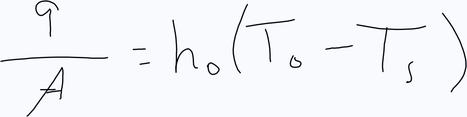

In [122]:
print(dataset_deepcopy['test'][1])
dataset_deepcopy['test'][1]['image']

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=356x80 at 0x7903FCC3BCB0>, 'latex': '\\langle a_{0},a_{1},...\\rangle\\in R^{\\omega}', 'sample_id': '728855ac96fa6bee', 'split_tag': 'test', 'data_type': 'human'}


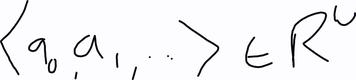

In [123]:
print(dataset_deepcopy['test'][2])
dataset_deepcopy['test'][2]['image']

# my own hadwritten 

In [124]:
!rm -rf /kaggle/working/my_photos

In [125]:
!wget -P /kaggle/working/my_photos https://raw.githubusercontent.com/Gagr300/smth/main/my/photo1.jpg
!wget -P /kaggle/working/my_photos https://raw.githubusercontent.com/Gagr300/smth/main/my/photo2.jpg
!wget -P /kaggle/working/my_photos https://raw.githubusercontent.com/Gagr300/smth/main/my/photo3.jpg
!wget -P /kaggle/working/my_photos https://raw.githubusercontent.com/Gagr300/smth/main/my/photo4.jpg
!wget -P /kaggle/working/my_photos https://raw.githubusercontent.com/Gagr300/smth/main/my/photo5.jpg
!wget -P /kaggle/working/my_photos https://raw.githubusercontent.com/Gagr300/smth/main/my/photo6.jpg

--2026-06-05 16:37:19--  https://raw.githubusercontent.com/Gagr300/smth/main/my/photo1.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 604024 (590K) [image/jpeg]
Saving to: ‘/kaggle/working/my_photos/photo1.jpg’

photo1.jpg          100%[===================>] 589.87K  --.-KB/s    in 0.04s   

2026-06-05 16:37:19 (14.3 MB/s) - ‘/kaggle/working/my_photos/photo1.jpg’ saved [604024/604024]

--2026-06-05 16:37:19--  https://raw.githubusercontent.com/Gagr300/smth/main/my/photo2.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 334

In [126]:
def load_images_from_folder(folder_path):
    image_extensions = {'.jpg', '.png'}
    images = []
    
    for filename in os.listdir(folder_path):
        if os.path.splitext(filename)[1].lower() in image_extensions:
            image_path = os.path.join(folder_path, filename)
            try:
                images.append(Image.open(image_path))
            except Exception as e:
                print(f"Ошибка загрузки {filename}: {e}")
    
    return images
my_images = load_images_from_folder('/kaggle/working/my_photos')

# useful functions

In [127]:
# convert_to_conversation function
instruction = "Write the correct LaTeX expression for the formula on the image"

def convert_to_conversation(sample):
    """Convert dataset sample to conversation format"""
    conversation = [
        {
            "role": "user",
            "content": [
           {"type": "text", "text": instruction},
           {"type": "image", "image": sample["image"]}

       ]
        },
        {
            "role": "assistant",
            "content": [
               {"type": "text", "text": sample["latex"]}
            ]
        },
    ]
    return conversation

In [128]:
train_ds = [convert_to_conversation(sample) for sample in dataset_linxy['train']]
eval_ds = [convert_to_conversation(sample) for sample in dataset_linxy['validation']]

In [129]:
test_target = [x['latex'] for x in dataset_linxy['test']]
test_target

['\\sqrt { b ^ { 2 } - 4 a c }',
 '\\sqrt { x - y - z + x ^ { 2 } + y ^ { 2 } + z ^ { 2 } }',
 '\\frac { 2 \\tan \\alpha } { 1 - \\tan ^ { 2 } \\alpha }',
 '\\lim _ { x \\rightarrow - 1 } \\frac { x ^ { 3 } + 1 } { x + 1 }',
 '1 + \\frac { 1 } { 1 ! } + \\frac { 1 } { 2 ! } + \\frac { 1 } { 3 ! } + \\frac { 1 } { 4 ! }',
 '\\lim _ { x \\rightarrow \\frac { \\pi } { 2 } + 0 } \\tan x = - \\infty',
 '\\int \\left( 2 ^ { x } - 3 e ^ { x } \\right) d x',
 '\\frac { 1 } { a } F \\left( a x + b \\right) + C',
 '\\frac { \\sin B + \\sin C } { \\cos B + \\cos C }',
 '\\alpha _ { n + 1 } - 3 \\beta = \\frac { 2 } { 3 } \\alpha _ { n } + \\beta - 3 \\beta',
 '3 0 \\times 2 9 x ^ { 2 8 }',
 '\\sqrt { 1 + \\sqrt { 2 + \\sqrt { 3 + \\sqrt { 4 } } } }',
 '\\frac { \\sin \\theta + \\cos \\theta + \\tan \\theta } { x + y + z }',
 '\\lim _ { x \\rightarrow \\frac { 1 } { 4 } } \\frac { 1 - 4 ^ { x - \\frac { 1 } { 4 } } } { 1 - 4 x }',
 'x _ { 1 } + x _ { 2 } = x _ { 3 }',
 'x _ { i } - x _ { i + 1 } +

### getting TexBleu

In [130]:
!wget -P /kaggle/working/TeXBLEU https://github.com/KyuDan1/TeXBLEU/raw/refs/heads/main/new_embeddings.pth

--2026-06-05 16:37:23--  https://github.com/KyuDan1/TeXBLEU/raw/refs/heads/main/new_embeddings.pth
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/KyuDan1/TeXBLEU/refs/heads/main/new_embeddings.pth [following]
--2026-06-05 16:37:23--  https://raw.githubusercontent.com/KyuDan1/TeXBLEU/refs/heads/main/new_embeddings.pth
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1215 (1.2K) [application/octet-stream]
Saving to: ‘/kaggle/working/TeXBLEU/new_embeddings.pth.2’

new_embeddings.pth. 100%[===================>]   1.19K  --.-KB/s    in 0s      

2026-06-05 16:37:23 (20.4 MB/s) - ‘/kaggle/working/TeXB

In [ ]:
"""
TexBLEU 
code was taken from https://github.com/KyuDan1/TeXBLEU/blob/main/new_metric.py
and modified a little
"""
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#print(f"Using device: {device}")

# 토크나이저 및 모델 로드를 함수 내부로 이동
def load_models_and_tokenizer():
    global tokenizer, gpt2_model, embedding_layer, positional_embedding, new_embeddings
    
    tokenizer = GPT2TokenizerFast.from_pretrained('gpt2')
    gpt2_model = GPT2Model.from_pretrained('gpt2')
    embedding_layer = gpt2_model.wte.to(device)
    positional_embedding = gpt2_model.wpe.to(device)

    # 새로운 임베딩 로드 (필요한 경우)
    try:
        if device == 'cuda':
            new_embeddings_state = torch.load('/kaggle/working/TeXBLEU/new_embeddings.pth')
        else:
            new_embeddings_state = torch.load('/kaggle/working/TeXBLEU/new_embeddings.pth', map_location=torch.device('cpu'))

        new_vocab_size, embedding_dim = new_embeddings_state['weight'].shape
        new_embeddings = torch.nn.Embedding(new_vocab_size, embedding_dim).to(device)
        new_embeddings.load_state_dict(new_embeddings_state)
    except FileNotFoundError:
        print("Warning: new_embeddings.pth not found. Using default embeddings.")
        new_embeddings = None


def spacing(text):
    result = []
    for i, char in enumerate(text):
        if char == "\\":
            if i == 0 or text[i-1] != " ":
                result.append(" \\")
            else:
                result.append("\\")
        else:
            result.append(char)
    return ''.join(result)


def get_token_embeddings(sentence):
    sentence = spacing(sentence)
    tokens = tokenizer.encode(sentence, truncation=True, max_length=512)
    #print(f"Tokenized text: {tokens}")
    decoded_tokens = [tokenizer.decode([token]) for token in tokens]
    #print(f"Decoded tokens: {decoded_tokens}")
    
    token_ids = torch.tensor(tokens).unsqueeze(0).to(device)
    positions = torch.arange(0, token_ids.size(1)).unsqueeze(0).to(device)
    
    if new_embeddings is not None:
        token_embeddings = torch.cat([embedding_layer.weight, new_embeddings.weight])[token_ids]
    else:
        token_embeddings = embedding_layer(token_ids)
    
    pos_embeddings = positional_embedding(positions) * 100
    
    
    return list(zip(token_embeddings[0], pos_embeddings[0]))

def cosine_distance(emb1, emb2):
    return 1 - torch.cosine_similarity(emb1.unsqueeze(0), emb2.unsqueeze(0)).item()

def token_distance(token1, token2, w_emb=0.5, w_pos=0.5, alpha=2, beta=0.1):
    emb1, pos1 = token1
    emb2, pos2 = token2
    
    # 임베딩 거리에 지수 적용
    emb_dist = cosine_distance(emb1, emb2) ** alpha
    
    # 위치 거리에 비선형성 추가
    pos_dist = math.tanh(beta * torch.abs(pos1 - pos2).float().mean().item())
    
    distance = w_emb * emb_dist + w_pos * pos_dist
    
    return distance

def n_gram_similarity(ref_tokens, pred_tokens, n, max_d=2.0):
    ref_ngrams = [ref_tokens[i:i+n] for i in range(len(ref_tokens)-n+1)]
    pred_ngrams = [pred_tokens[i:i+n] for i in range(len(pred_tokens)-n+1)]
    
    L_n = min(len(ref_ngrams), len(pred_ngrams))
    if L_n == 0:
        return 0
    
    # core part //author
    total_distance = sum(
        sum(token_distance(ref_token, pred_token) 
            for ref_token, pred_token in zip(ref_ngram, pred_ngram))
        for ref_ngram, pred_ngram in zip(ref_ngrams[:L_n], pred_ngrams[:L_n])
    )
    
    return 1 - (total_distance / (L_n * n)) #1 - (total_distance / (L_n * n * max_d))

def texbleu(reference, prediction, max_n=2, weights=None):
    if weights is None:
        weights = [1/max_n] * max_n
    
    ref_tokens = get_token_embeddings(reference)
    pred_tokens = get_token_embeddings(prediction)
    
    n_gram_scores = [n_gram_similarity(ref_tokens, pred_tokens, n) 
                     for n in range(1, max_n+1)]
    
    # 길이 계산
    ref_length = len(ref_tokens)
    pred_length = len(pred_tokens)
    
    # Brevity penalty 계산
    if pred_length > ref_length:
        bp = 1
    else:
        bp = math.exp(1 - ref_length / pred_length)
    
    # 길이 차이에 대한 추가 페널티 계산
    length_ratio = min(ref_length, pred_length) / max(ref_length, pred_length)
    
    # BLEU 점수 계산
    bleu_score = math.exp(sum(w * math.log(max(s, 1e-10)) 
                      for w, s in zip(weights, n_gram_scores)))
    
    # 길이 페널티를 적용한 최종 점수 계산
    final_score = bleu_score # * length_ratio
    
    return round(final_score, 4)


load_models_and_tokenizer()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [ ]:
# evaluate function
def evaluate(predictions: List[str], references: List[str],) -> Dict[str, float]:
    
    metrics = {}
    
    # Perplexity 
    # metrics['perplexity'] = compute_perplexity(predictions, model, processor)

    # Edit Distance
    edit_distances = []
    for pred, ref in zip(predictions, references):
        distance = editdistance.eval(pred, ref)
        max_len = max(len(pred), len(ref))
        normalized_distance = distance / max_len if max_len > 0 else 0
        edit_distances.append(normalized_distance)
    metrics['edit_distance'] = np.mean(edit_distances)
    
    # BLEU-4
    bleu_scores = []
    smoothing = SmoothingFunction().method1
    
    for pred, ref in zip(predictions, references):
        # Токенизация для BLEU (разбиваем на слова)
        pred_tokens = pred.split()
        ref_tokens = [ref.split()]  # BLEU ожидает список референсов
        
        bleu = sentence_bleu(
            ref_tokens, 
            pred_tokens, 
            weights=(0.25, 0.25, 0.25, 0.25),  # BLEU-4
            smoothing_function=smoothing
        )
        bleu_scores.append(bleu)
    
    metrics['bleu4'] = np.mean(bleu_scores)

    # TeXBLEU
    metrics['texbleu'] = np.mean([texbleu(ref, cand) for ref, cand in zip(references, predictions)])
    
    
    # Exact Match Score
    exact_matches = [1 if pred.strip() == ref.strip() else 0 
                     for pred, ref in zip(predictions, references)]
    metrics['matches'] = [1 if pred.strip() == ref.strip() else 0 
                     for pred, ref in zip(predictions, references)]
    metrics['exact_match'] = np.mean(exact_matches)
    
    return metrics

# Zero-shot

In [133]:
# show first sample
dataset_linxy['test'][0]

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=515x213>,
 'latex': '\\sqrt { b ^ { 2 } - 4 a c }'}

In [ ]:
# first test sample inference 
sample = dataset_linxy['test'][0]
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": sample['image'],
            },
            {"type": "text", "text": instruction},
        ],
    }
]

inputs = processor.apply_chat_template(
    [messages],
    tokenize=True,
    add_generation_prompt=True,
    return_dict=True,
    return_tensors="pt"
)
inputs = inputs.to(model.device)

generated_ids = model.generate(**inputs, max_new_tokens=128)
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
print(output_text)

['```latex\n\\sqrt{b^2 - 4ac}\n```']


we can notice lack of spaces and extra '\```latex'  '```'

In [135]:
outputs = []

for sample in tqdm(dataset_linxy['test'], desc="Generating"):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": sample['image']},
                {"type": "text", "text": instruction},
            ],
        }
    ]
    
    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt"
    ).to(model.device)
    
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs, 
            max_new_tokens=128,
            do_sample=False,
            pad_token_id=processor.tokenizer.pad_token_id
        )
    
    response = processor.decode(
        generated_ids[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    )
    
    outputs.append(response)

Generating: 100%|██████████| 70/70 [02:47<00:00,  2.39s/it]


In [136]:
ev = evaluate(outputs, test_target)
ev

{'edit_distance': np.float64(0.5532609347264613),
 'bleu4': np.float64(0.07669236658826704),
 'texbleu': np.float64(0.7593071428571426),
 'matches': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'exact_match': np.float64(0.0)}

In [137]:
# for i, j in enumerate(ev['matches']):
#     if j == 0:
#         image = dataset_linxy['test'][i]['image']  # This returns a PngImageFile object
#         display(image)

In [138]:
outputs

['```latex\n\\sqrt{b^2 - 4ac}\n```',
 '$$\\sqrt{x - y - z + x^2 + y^2 + z^2}$$',
 '```latex\n\\frac{2 \\tan \\alpha}{1 - \\tan^2 \\alpha}\n```',
 '$$\\lim_{x \\to -1} \\frac{x^3 + 1}{x + 1}$$',
 '```latex\n1 + \\frac{1}{1!} + \\frac{1}{2!} + \\frac{1}{3!} + \\frac{1}{4!}\n```',
 '$$\n\\lim_{x \\to \\frac{\\pi}{2}^+} \\tan x = -\\infty\n$$',
 '$$\\int (2^x - 3e^x) \\, dx$$',
 '```latex\n\\frac{1}{a}F(ax+b)+c\n```',
 '```latex\n\\frac{\\sin B + \\sin C}{\\cos B + \\cos C}\n```',
 '```latex\nx_{n+1} - 3\\beta = \\frac{2}{3}x_n + \\beta - 3\\beta\n```',
 '$$30 \\times 29x^{28}$$',
 '```latex\n\\sqrt{1 + \\sqrt{2 + \\sqrt{3 + \\sqrt{4}}}}\n```',
 '```latex\n\\frac{\\sin\\theta + \\cos\\theta + \\tan\\theta}{x+y+z}\n```',
 '$$\\lim_{x \\to \\frac{1}{4}} \\frac{1 - 4^{x - \\frac{1}{4}}}{1 - 4x}$$',
 '```latex\nx_1 + x_2 = x_3\n```',
 '```latex\nx_i - x_{i+1} + x_{i+2}\n```',
 '```latex\n\\sqrt{b^2 - 4ac}\n```',
 '```latex\n\\sqrt{x - y - z + x^2 + y^2 + z^2}\n```',
 '```latex\n\\frac{\\sin\\t

### with my photos

In [139]:
outputs = []

for sample in my_images:
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": sample},
                {"type": "text", "text": instruction},
            ],
        }
    ]
    
    inputs = processor.apply_chat_template(
        [messages],
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt"
    ).to(model.device)
    
    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=128)
    
    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )
    
    print(output_text[0], '\n')

```latex
\sqrt{x - y + z - x^2 + y^2 + z^3} = 100
``` 

```latex
x + y + z \approx 8
``` 

```latex
D_{KL}(x||y)
``` 

```latex
x + y + z \approx 8
``` 

```latex
\sqrt{x - y + z - x^2 + y^2 + z^3} = 100
``` 

```latex
P_{KL}(x|y)
``` 



# Few-shot 

## one-shot

In [ ]:
one_shot_outputs = []

example = dataset_linxy['validation'][0]

for sample in tqdm(dataset_linxy['test'], desc="Generating"):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": example['image']},
                {"type": "text", "text": instruction},
            ],
        },
        {
            "role": "assistant",
            "content": example["latex"]
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": sample['image']},
                {"type": "text", "text": instruction},
            ],
        }
    ]
    
    prompt = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    
    images = [example['image'], sample['image']]
    
    inputs = processor(
        text=prompt,
        images=images,
        padding=True,
        return_tensors="pt"
    ).to(model.device)
    
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=128,
            temperature=0.1,
            do_sample=False,
            pad_token_id=processor.tokenizer.pad_token_id
        )
    
    response = processor.decode(
        generated_ids[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    )
    
    one_shot_outputs.append(response)

Generating: 100%|██████████| 70/70 [02:52<00:00,  2.47s/it]


In [141]:
ev = evaluate(one_shot_outputs, test_target)
ev

{'edit_distance': np.float64(0.3236227688345772),
 'bleu4': np.float64(0.3341351385408968),
 'texbleu': np.float64(0.78631),
 'matches': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'exact_match': np.float64(0.014285714285714285)}

In [142]:
# for i, j in enumerate(ev['matches']):
#     if j == 0:
#         image = dataset_linxy['test'][i]['image']  # This returns a PngImageFile object
#         display(image)

In [143]:
one_shot_outputs

['```latex\n\\sqrt{b^2 - 4ac}\n```',
 '```latex\n\\sqrt{x - y - z + x^2 + y^2 + z^2}\n```',
 '$$\\frac { 2 \\tan \\alpha } { 1 - \\tan ^ { 2 } \\alpha }$$',
 '$$\\lim_{x \\to -1} \\frac{x^3 + 1}{x + 1}$$',
 '$$1 + \\frac{1}{1!} + \\frac{1}{2!} + \\frac{1}{3!} + \\frac{1}{4!}$$',
 '$$\\lim_{x \\to \\frac{\\pi}{2}^+} \\tan x = -\\infty$$',
 '$$\\int (2x - 3e^x) \\, dx$$',
 '$$\\frac { 1 } { a } F ( a x + b ) + c$$',
 '\\frac{\\sin B + \\sin C}{\\cos B + \\cos C}',
 '$$x _ { n + 1 } - 3 \\beta = \\frac { 2 } { 3 } x _ { n } + \\beta - 3 \\beta$$',
 '$$30 \\times 29x^{28}$$',
 '```latex\n\\sqrt{1 + \\sqrt{2 + \\sqrt{3 + \\sqrt{4}}}}\n```',
 '\\frac{\\sin \\theta + \\cos \\theta + \\tan \\theta}{x + y + z}',
 '$$\\lim_{x \\to \\frac{1}{4}} \\frac{1 - 4^{-\\frac{1}{4}}}{1 - 4x}$$',
 '$$x _ { 1 } + x _ { 2 } = x _ { 3}$$',
 '$$x_{i} - x_{i+1} + x_{i+2}$$',
 '\\sqrt{b^2 - 4ac}',
 '```latex\n\\sqrt{x - y - z + x^2 + y^2 + z^2}\n```',
 '\\frac{\\sin \\theta + \\cos \\theta + \\tan \\theta}{x + y

### with my photos

In [ ]:
example = dataset_linxy['validation'][0]

for sample in my_images:
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": example['image']},
                {"type": "text", "text": instruction},
            ],
        },
        {
            "role": "assistant",
            "content": example["latex"]
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": sample},
                {"type": "text", "text": instruction},
            ],
        }
    ]
    
    prompt = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    
    images = [example['image'], sample]
    
    inputs = processor(
        text=prompt,
        images=images,
        padding=True,
        return_tensors="pt"
    ).to(model.device)
    
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=128,
            temperature=0.1,
            do_sample=False,
            pad_token_id=processor.tokenizer.pad_token_id
        )
    
    response = processor.decode(
        generated_ids[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    )
    
    print(response,'\n')


```latex
\sqrt{x - y + z - x^2 + y^2 + z^3} = 100
``` 

```latex
x + y + z \approx 8
``` 

```latex
\mathrm{P}_{\mathrm{K}} \left( x \, \mathrm{I} \, y \right)
``` 

```latex
x + y + z \approx 8
``` 

```latex
\sqrt{x - y + z - x^2 + y^2 + z^3} = 100
``` 

```latex
\mathrm{P}_{\mathrm{K}} \left( x \mid y \right)
``` 



## two-shot

In [145]:
two_shot_outputs = []

examples = [dataset_linxy['validation'][0], dataset_linxy['validation'][1]]

for sample in tqdm(dataset_linxy['test'], desc="Generating"):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": examples[0]['image']},
                {"type": "text", "text": instruction},
            ],
        },
        {
            "role": "assistant",
            "content": examples[0]["latex"]
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": examples[1]['image']},
                {"type": "text", "text": instruction},
            ],
        },
        {
            "role": "assistant",
            "content": examples[1]["latex"]
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": sample['image']},
                {"type": "text", "text": instruction},
            ],
        }
    ]
    
    # Получаем промпт в текстовом виде
    prompt = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    
    # Собираем изображения
    images = [examples[0]['image'], examples[1]['image'], sample['image']]
    
    # ВАЖНО: используем processor с правильными ключами
    # НЕ передаём prompt как позиционный аргумент, а через ключ 'text'
    inputs = processor(
        text=prompt,  # Явно указываем 'text'
        images=images,
        padding=True,
        return_tensors="pt"
    ).to(model.device)
    
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=128,
            temperature=0.1,
            do_sample=False,
            pad_token_id=processor.tokenizer.pad_token_id
        )
    
    # Декодируем только новые токены
    response = processor.decode(
        generated_ids[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    )
    
    two_shot_outputs.append(response)

Generating: 100%|██████████| 70/70 [02:44<00:00,  2.35s/it]


In [146]:
ev = evaluate(two_shot_outputs, test_target)
ev

{'edit_distance': np.float64(0.29282285595893404),
 'bleu4': np.float64(0.3922241380632231),
 'texbleu': np.float64(0.8394471428571428),
 'matches': [1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  1,
  1,
  0,
  0,
  1,
  0,
  1,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  0,
  1,
  0,
  0,
  1],
 'exact_match': np.float64(0.22857142857142856)}

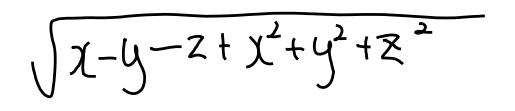

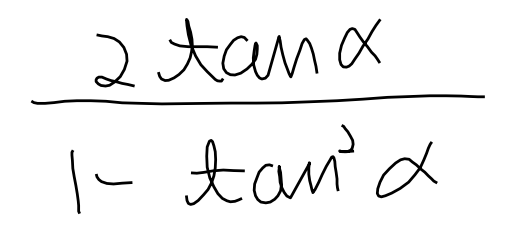

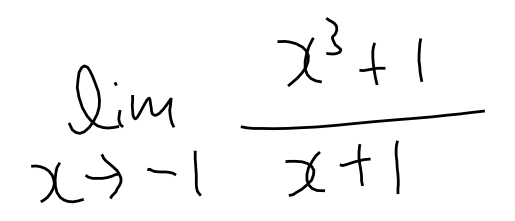

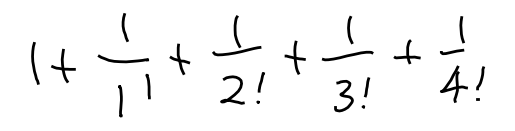

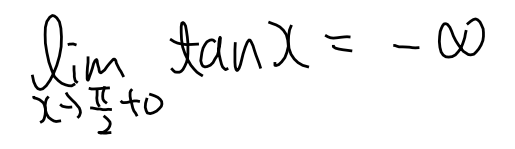

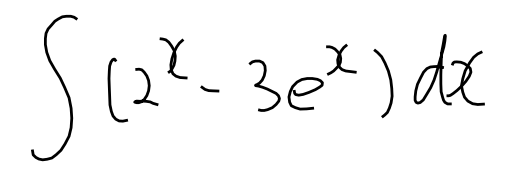

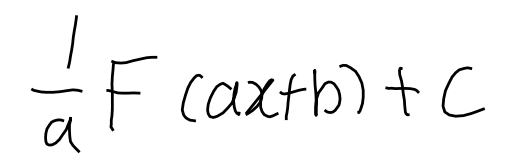

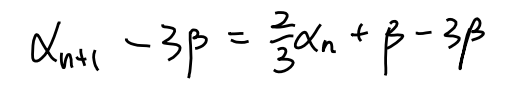

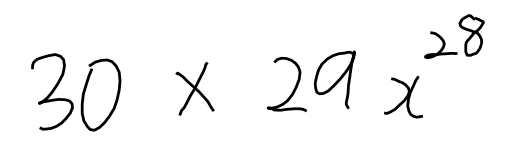

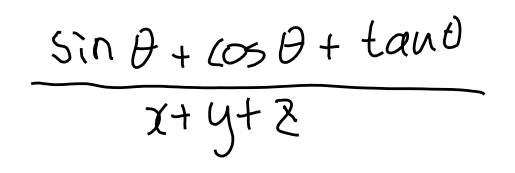

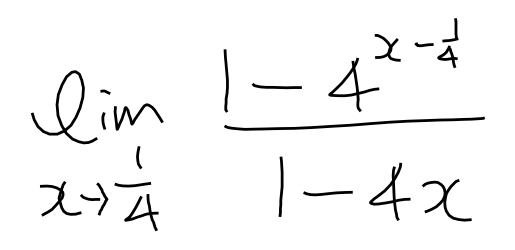

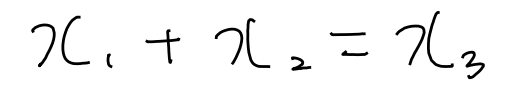

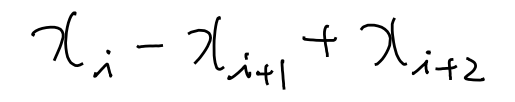

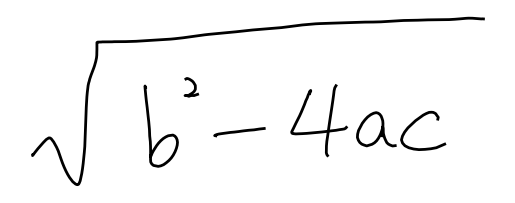

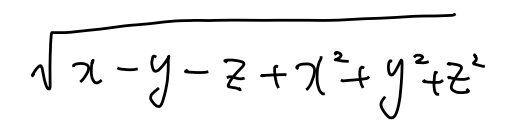

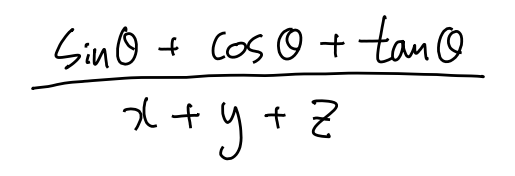

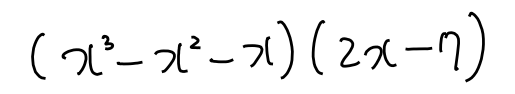

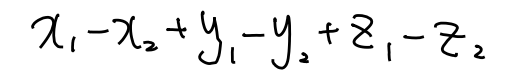

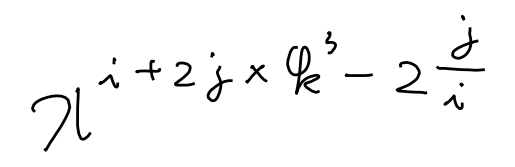

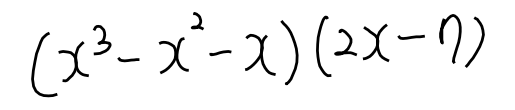

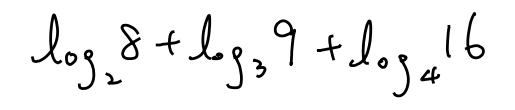

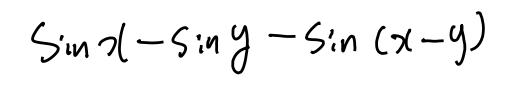

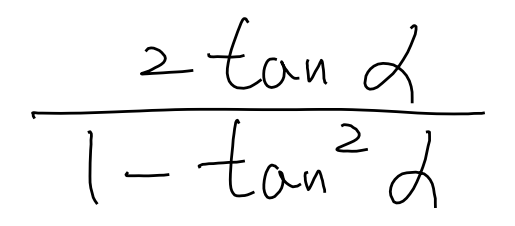

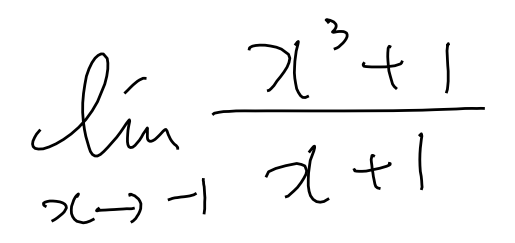

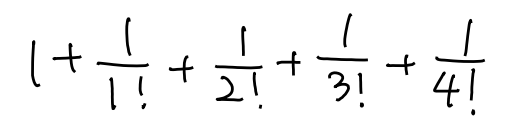

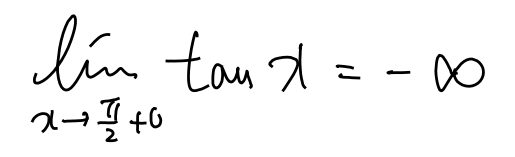

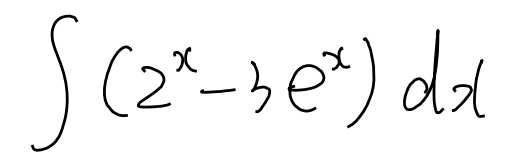

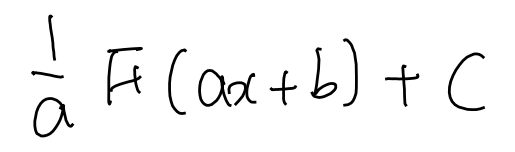

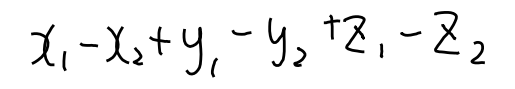

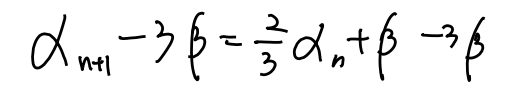

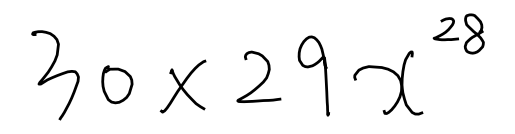

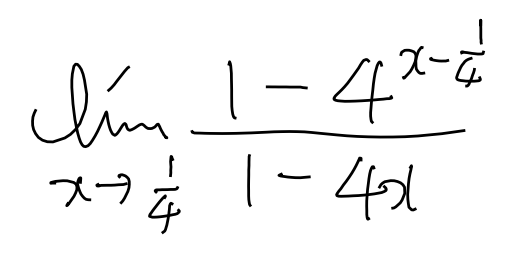

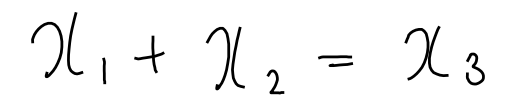

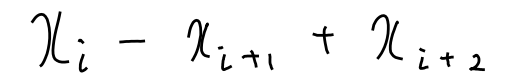

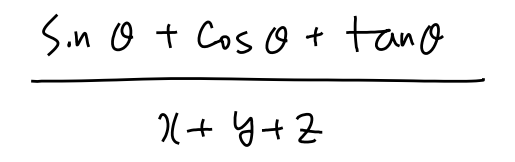

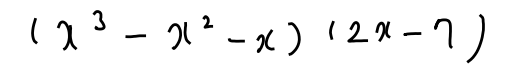

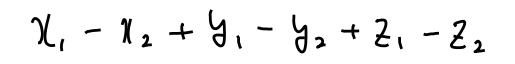

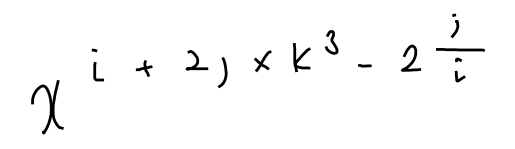

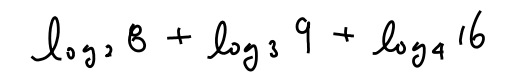

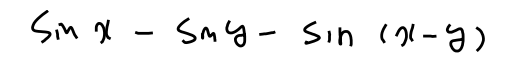

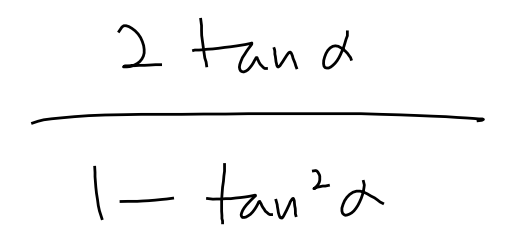

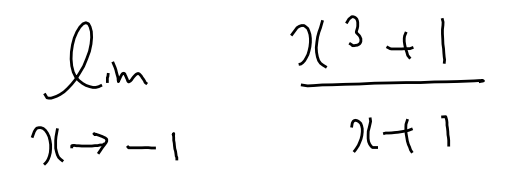

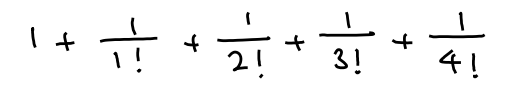

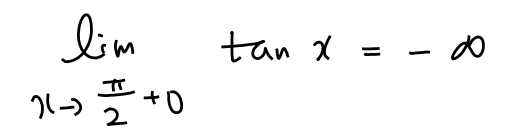

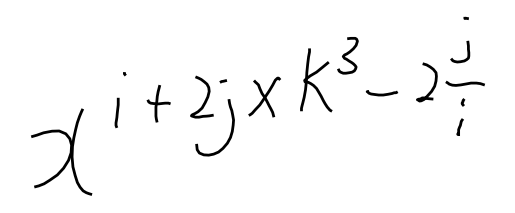

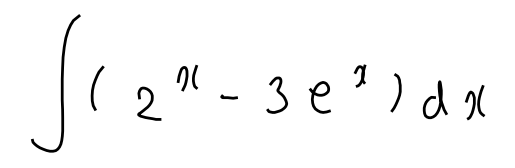

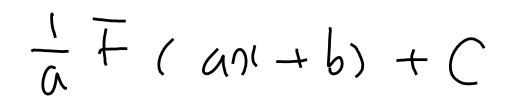

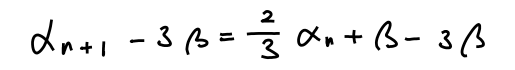

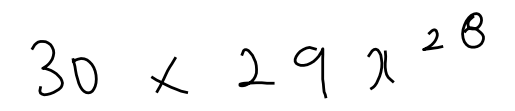

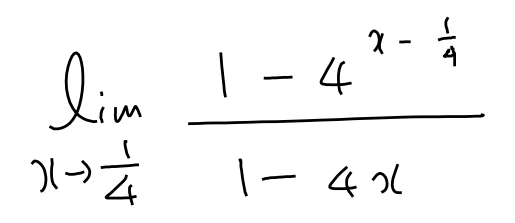

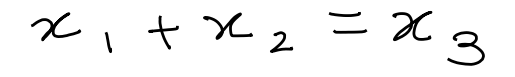

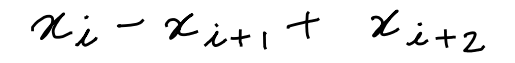

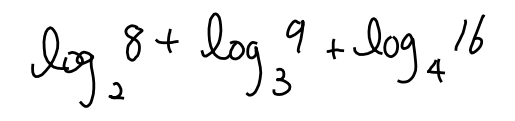

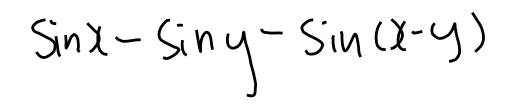

In [147]:
for i, j in enumerate(ev['matches']):
    if j == 0:
        image = dataset_linxy['test'][i]['image']  # This returns a PngImageFile object
        display(image)

In [148]:
two_shot_outputs

['\\sqrt { b ^ { 2 } - 4 a c }',
 '\\sqrt{x - y - z + x^2 + y^2 + z^2}',
 '\\frac { 2 \\tan \\alpha } { 1 - \\tan^2 \\alpha }',
 '\\lim_{x \\to -1} \\frac{x^3 + 1}{x + 1}',
 '\\frac{1}{1!} + \\frac{1}{2!} + \\frac{1}{3!} + \\frac{1}{4!}',
 '$$\n\\lim_{x \\to \\frac{\\pi}{2}^+} \\tan x = -\\infty\n$$',
 '\\int (2^x - 3e^x) \\, dx',
 '\\frac{1}{a}F(ax+b)+c',
 '\\frac { \\sin B + \\sin C } { \\cos B + \\cos C }',
 '$$x _ { n + 1 } - 3 \\beta = \\frac { 2 } { 3 } x _ { n } + \\beta - 3 \\beta$$',
 '$$30 \\times 29x^{28}$$',
 '\\sqrt { 1 + \\sqrt { 2 + \\sqrt { 3 + \\sqrt { 4 } } } }',
 '$$\n\\frac{\\sin \\theta + \\cos \\theta + \\tan \\theta}{x + y + z}\n$$',
 '\\lim_{x \\to \\frac{1}{4}} \\frac{1 - 4^{x - \\frac{1}{4}}}{1 - 4x}',
 '$$x _ { 1 } + x _ { 2 } = x _ { 3}$$',
 '$x_{i} - x_{i+1} + x_{i+2}$',
 '\\sqrt { b^2 - 4ac }',
 '$$\n\\sqrt { x - y - z + x ^ { 2 } + y ^ { 2 } + z ^ { 2 } }\n$$',
 '$$\n\\frac{\\sin \\theta + \\cos \\theta + \\tan \\theta}{x + y + z}\n$$',
 '$(x^3 - x^2 - x)

### with my photos

In [ ]:
for sample in my_images:
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": examples[0]['image']},
                {"type": "text", "text": instruction},
            ],
        },
        {
            "role": "assistant",
            "content": examples[0]["latex"]
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": examples[1]['image']},
                {"type": "text", "text": instruction},
            ],
        },
        {
            "role": "assistant",
            "content": examples[1]["latex"]
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": sample},
                {"type": "text", "text": instruction},
            ],
        }
    ]
    
    prompt = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    
    images = [examples[0]['image'], examples[1]['image'], sample]
    
    inputs = processor(
        text=prompt,
        images=images,
        padding=True,
        return_tensors="pt"
    ).to(model.device)
    
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=128,
            temperature=0.1,
            do_sample=False,
            pad_token_id=processor.tokenizer.pad_token_id
        )
    
    response = processor.decode(
        generated_ids[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    )
    
    print(response,'\n')


\sqrt { x - y + z - x ^ { 2 } + y ^ { 2 } + z ^ { 3 } } = 100 

$$x + y + z \approx 8$$ 

\mathrm{P}_{\mathrm{K}}\left(x \, \mathrm{I} \, y\right) 

$$x + y + z \approx 8$$ 

\sqrt { x - y + z - x ^ { 2 } + y ^ { 2 } + z ^ { 3 } } = 100 

$$
\mathrm { P } _ { \mathrm { k } \mathrm { l } } ( x \mid y )
$$ 



# SFT using linxy/LaTeX_OCR:train

In [ ]:
OPTIM = "adamw_8bit"
LEARNING_RATE = 2e-4
LR_SCHEDULER_TYPE = "cosine" 

LOGGING_STEPS = 20
EVAL_STEPS = 20
SAVE_STEPS = 20
EVAL_STRATEGY = "steps"
SAVE_STRATEGY = "steps"
SAVE_TOTAL_LIMIT = 2

LORA_RANK = 16
LORA_ALPHA = 16
LORA_DROPOUT = 0

EPOCHS = 2
BATCH_SIZE = 2
GRADIENT_ACCUMULATION_STEPS = 4 

WEIGHT_DECAY = 0.001
WARMUP_STEPS = 4

REMOVE_UNUSED_COLUMNS = False
DATASET_KWARGS = {"skip_prepare_dataset": True}

METRIC_FOR_BEST_MODEL="eval_loss"
LOAD_BEST_MODEL_AT_END = True

In [ ]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True, 
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True, 

    r = LORA_RANK,           
    lora_alpha = LORA_ALPHA,  
    lora_dropout = LORA_DROPOUT,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  
    loftq_config = None, 
    # target_modules = "all-linear",
)

FastVisionModel.for_training(model)

trainer = SFTTrainer(
    model = model,
    tokenizer = processor,
    data_collator = UnslothVisionDataCollator(
        model,
        processor,
        train_on_responses_only=True
    ), 
    train_dataset = train_ds,
    eval_dataset = eval_ds,
    args = SFTConfig(
        per_device_train_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        warmup_steps=WARMUP_STEPS,
        num_train_epochs=EPOCHS,
        learning_rate=LEARNING_RATE,
        optim=OPTIM,
        weight_decay=WEIGHT_DECAY,
        lr_scheduler_type=LR_SCHEDULER_TYPE,
        seed=3407,
        output_dir="outputs",
        report_to="none",   
        logging_steps=LOGGING_STEPS,
        save_strategy=SAVE_STRATEGY,
        save_steps=SAVE_STEPS,
        save_total_limit=SAVE_TOTAL_LIMIT, 
        metric_for_best_model=METRIC_FOR_BEST_MODEL,
        load_best_model_at_end=LOAD_BEST_MODEL_AT_END,
        eval_strategy=EVAL_STRATEGY,
        eval_steps=EVAL_STEPS,
        
        remove_unused_columns=REMOVE_UNUSED_COLUMNS,
        dataset_text_field="",
        dataset_kwargs=DATASET_KWARGS,
        max_length=MAX_LENGTH,
    ),
)

Unsloth: Model does not have a default image size - using 512


In [ ]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.563 GB.
2.326 GB of memory reserved.


In [ ]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 2
   \\   /|    Num examples = 1,200 | Num Epochs = 2 | Total steps = 300
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 23,724,032 of 2,151,256,064 (1.10% trained)


Step,Training Loss,Validation Loss
20,0.287237,0.040270
40,0.059893,0.018423
60,0.035506,0.012837
80,0.034385,0.013942
100,0.045515,0.014600
120,0.028205,0.010248
140,0.029757,0.008731
160,0.027685,0.008607
180,0.007599,0.008135
200,0.010501,0.008241


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-60/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-80/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-100/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-120/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-140/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-160/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-180/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-220/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-240/tokenizer_config.json.
Unsloth: Restored added_tokens_d

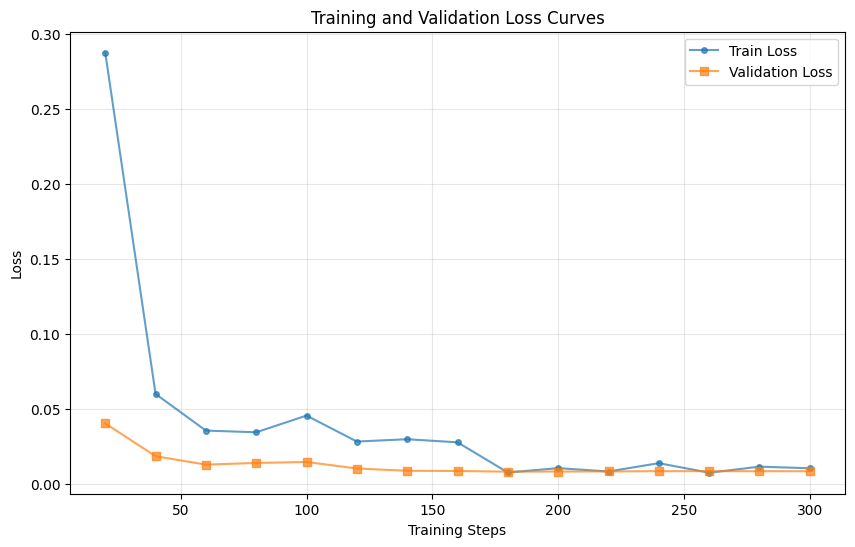

In [ ]:
# loss curves
eval_logs = [log for log in trainer.state.log_history if 'eval_loss' in log]
eval_steps = [log['step'] for log in eval_logs]
eval_losses = [log['eval_loss'] for log in eval_logs]

train_logs = [log for log in trainer.state.log_history if 'loss' in log and 'eval_loss' not in log]
train_steps = [log['step'] for log in train_logs]
train_losses = [log['loss'] for log in train_logs]

plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_losses, 'o-', label='Train Loss', alpha=0.7, markersize=4)
plt.plot(eval_steps, eval_losses, 's-', label='Validation Loss', alpha=0.7, markersize=6)

plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [156]:
outputs = []

for sample in tqdm(dataset_linxy['test'], desc="Generating"):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": sample['image']},
                {"type": "text", "text": instruction},
            ],
        }
    ]
    
    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt"
    ).to(model.device)
    
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs, 
            max_new_tokens=128,
            do_sample=False,
            pad_token_id=processor.tokenizer.pad_token_id
        )
    
    response = processor.decode(
        generated_ids[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    )
    
    outputs.append(response)

Generating: 100%|██████████| 70/70 [04:42<00:00,  4.03s/it]


In [ ]:
ev = evaluate(outputs, test_target)
ev

{'edit_distance': np.float64(0.005799488695304938),
 'bleu4': np.float64(0.9820071284132069),
 'texbleu': np.float64(0.9945314285714285),
 'matches': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1],
 'exact_match': np.float64(0.9285714285714286)}

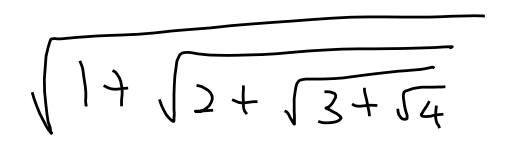

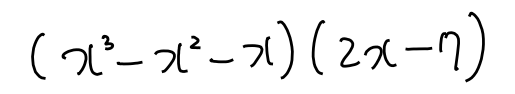

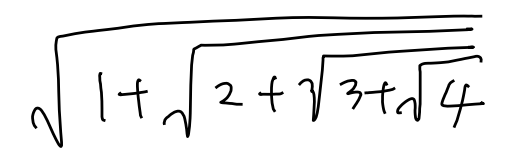

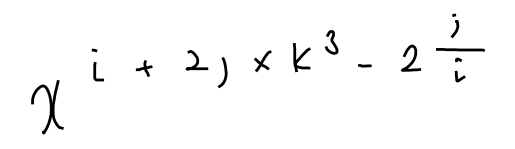

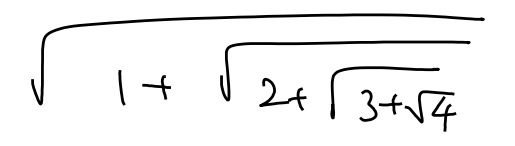

In [ ]:
for i, j in enumerate(ev['matches']):
    if j == 0:
        image = dataset_linxy['test'][i]['image']  # This returns a PngImageFile object
        display(image)

In [ ]:
outputs

['\\sqrt { b ^ { 2 } - 4 a c }',
 '\\sqrt { x - y - z + x ^ { 2 } + y ^ { 2 } + z ^ { 2 } }',
 '\\frac { 2 \\tan \\alpha } { 1 - \\tan ^ { 2 } \\alpha }',
 '\\lim _ { x \\rightarrow - 1 } \\frac { x ^ { 3 } + 1 } { x + 1 }',
 '1 + \\frac { 1 } { 1 ! } + \\frac { 1 } { 2 ! } + \\frac { 1 } { 3 ! } + \\frac { 1 } { 4 ! }',
 '\\lim _ { x \\rightarrow \\frac { \\pi } { 2 } + 0 } \\tan x = - \\infty',
 '\\int \\left( 2 ^ { x } - 3 e ^ { x } \\right) d x',
 '\\frac { 1 } { a } F \\left( a x + b \\right) + C',
 '\\frac { \\sin B + \\sin C } { \\cos B + \\cos C }',
 '\\alpha _ { n + 1 } - 3 \\beta = \\frac { 2 } { 3 } \\alpha _ { n } + \\beta - 3 \\beta',
 '3 0 \\times 2 9 x ^ { 2 8 }',
 '\\sqrt { 1 + \\sqrt { 2 + \\sqrt { 3 + \\sqrt 4 } } }',
 '\\frac { \\sin \\theta + \\cos \\theta + \\tan \\theta } { x + y + z }',
 '\\lim _ { x \\rightarrow \\frac { 1 } { 4 } } \\frac { 1 - 4 ^ { x - \\frac { 1 } { 4 } } } { 1 - 4 x }',
 'x _ { 1 } + x _ { 2 } = x _ { 3 }',
 'x _ { i } - x _ { i + 1 } + x _

In [ ]:
outputs = []

for sample in my_images:
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": sample},
                {"type": "text", "text": instruction},
            ],
        }
    ]
    
    inputs = processor.apply_chat_template(
        [messages],
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt"
    ).to(model.device)
    
    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=128)
    
    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )
    
    print(output_text[0], '\n')

\sqrt { x - y + z - x ^ { 2 } + y ^ { 2 } + z ^ { 3 } } = 1 0 0 

x + y + z \approx 8 

P _ { k \underline { { L } } } ( X \mid Y ) 

P _ { k \underline { { L } } } ( X 1 1 Y ) 

\sqrt { x - y + z - x ^ { 2 } + y ^ { 2 } + z ^ { 3 } } = 1 0 0 

x + y + z \approx 8 



In [ ]:
model.save_pretrained("./my_first_lora_adapter")
processor.save_pretrained("./my_first_lora_adapter")

['./my_first_lora_adapter/processor_config.json']

In [162]:
!tar -cf qwen-vl.tar /kaggle/working/my_first_lora_adapter

tar: Removing leading `/' from member names


# SFT using linxy/LaTeX_OCR:train + deepcopy/MathWriting-huma

In [163]:
train_ds.extend([convert_to_conversation(sample) for sample in dataset_deepcopy['train']])

In [175]:
EPOCHS = 2
BATCH_SIZE = 4
LEARNING_RATE = 2e-5
LOGGING_STEPS = 20
EVAL_STEPS = 100
SAVE_STEPS = 100

In [176]:
model, processor = FastVisionModel.from_pretrained(
    MODEL_ID,
    load_in_4bit=True,
    max_seq_length=MAX_LENGTH,
    dtype=torch.float16,
    device_map = "auto",
    use_gradient_checkpointing = "unsloth"
)

==((====))==  Unsloth 2026.6.1: Fast Qwen3_Vl patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

In [ ]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True, 
    finetune_language_layers   = True, 
    finetune_attention_modules = True, 
    finetune_mlp_modules       = True, 

    r = LORA_RANK,          
    lora_alpha = LORA_ALPHA, 
    lora_dropout = LORA_DROPOUT,
    bias = "none",
    random_state = 3407,
    use_rslora = False, 
    loftq_config = None, 
    # target_modules = "all-linear",
)

FastVisionModel.for_training(model)

trainer = SFTTrainer(
    model = model,
    tokenizer = processor,
    data_collator = UnslothVisionDataCollator(
        model,
        processor,
        train_on_responses_only=True
    ), 
    train_dataset = train_ds,
    eval_dataset = eval_ds,
    args = SFTConfig(
        per_device_train_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        warmup_steps=WARMUP_STEPS,
        num_train_epochs=EPOCHS,
        learning_rate=LEARNING_RATE,
        optim=OPTIM,
        weight_decay=WEIGHT_DECAY,
        lr_scheduler_type=LR_SCHEDULER_TYPE,
        seed=3407,
        output_dir="outputs",
        report_to="none",    
        logging_steps=LOGGING_STEPS,
        save_strategy=SAVE_STRATEGY,
        save_steps=SAVE_STEPS,
        save_total_limit=SAVE_TOTAL_LIMIT, 
        metric_for_best_model=METRIC_FOR_BEST_MODEL,
        load_best_model_at_end=LOAD_BEST_MODEL_AT_END,
        eval_strategy=EVAL_STRATEGY,
        eval_steps=EVAL_STEPS,

        remove_unused_columns=REMOVE_UNUSED_COLUMNS,
        dataset_text_field="",
        dataset_kwargs=DATASET_KWARGS,
        max_length=MAX_LENGTH,
    ),
)

Unsloth: Model does not have a default image size - using 512


In [178]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 2
   \\   /|    Num examples = 12,693 | Num Epochs = 2 | Total steps = 1,588
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 23,724,032 of 2,151,256,064 (1.10% trained)


Step,Training Loss,Validation Loss
100,0.198224,0.101914
200,0.135826,0.045063
300,0.137145,0.030652
400,0.116413,0.021836
500,0.117925,0.019939
600,0.118519,0.022534
700,0.114187,0.018197
800,0.110705,0.017585
900,0.097291,0.013851
1000,0.098074,0.013773


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-500/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-600/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-700/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-800/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-900/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-1000/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-1100/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-1200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-1300/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-1400/tokenizer_config.json.
Unsloth: Restored added_t

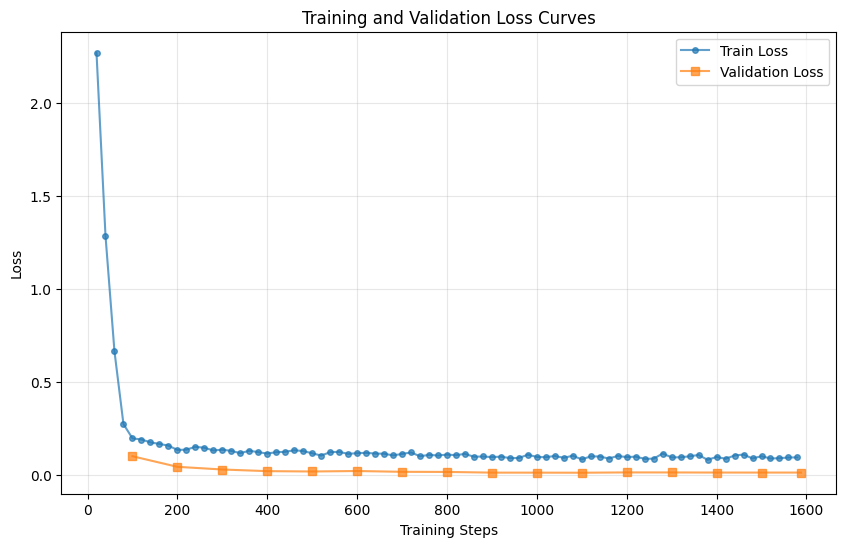

In [ ]:
# loss curve
eval_logs = [log for log in trainer.state.log_history if 'eval_loss' in log]
eval_steps = [log['step'] for log in eval_logs]
eval_losses = [log['eval_loss'] for log in eval_logs]

train_logs = [log for log in trainer.state.log_history if 'loss' in log and 'eval_loss' not in log]
train_steps = [log['step'] for log in train_logs]
train_losses = [log['loss'] for log in train_logs]

plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_losses, 'o-', label='Train Loss', alpha=0.7, markersize=4)
plt.plot(eval_steps, eval_losses, 's-', label='Validation Loss', alpha=0.7, markersize=6)

plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [180]:
outputs = []

for sample in tqdm(dataset_linxy['test'], desc="Generating"):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": sample['image']},
                {"type": "text", "text": instruction},
            ],
        }
    ]
    
    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt"
    ).to(model.device)
    
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs, 
            max_new_tokens=128,
            do_sample=False,
            pad_token_id=processor.tokenizer.pad_token_id
        )
    
    response = processor.decode(
        generated_ids[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    )
    
    outputs.append(response)

Generating: 100%|██████████| 70/70 [04:20<00:00,  3.71s/it]


In [181]:
evaluate(outputs, test_target)
ev

{'edit_distance': np.float64(0.004476737372553615),
 'bleu4': np.float64(0.9866480612921066),
 'texbleu': np.float64(0.9962114285714286),
 'matches': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1],
 'exact_match': np.float64(0.9428571428571428)}

In [182]:
outputs

['\\sqrt{b^{2}-4ac}',
 '\\sqrt { x - y - z + x ^ { 2 } + y ^ { 2 } + z ^ { 2 } }',
 '\\frac { 2 \\tan \\alpha } { 1 - \\tan ^ { 2 } \\alpha }',
 '\\lim _ { x \\rightarrow - 1 } \\frac { x ^ { 3 } + 1 } { x + 1 }',
 '1+\\frac{1}{1!}+\\frac{1}{2!}+\\frac{1}{3!}+\\frac{1}{4!}',
 '\\lim _ { x \\rightarrow \\frac { \\pi } { 2 } + 0 } \\tan x = - \\infty',
 '\\int(2^{x}-3e^{x})dx',
 '\\frac { 1 } { a } F ( a x + b ) + C',
 '\\frac { \\sin B + \\sin C } { \\cos B + \\cos C }',
 '\\alpha_{n + 1} - 3 \\beta = \\frac { 2 } { 3 } \\alpha _ { n } + \\beta - 3 \\beta',
 '3 0 \\times 2 9 x ^ { 2 8 }',
 '\\sqrt { 1 + \\sqrt { 2 + \\sqrt { 3 + \\sqrt 4 } } }',
 '\\frac { \\sin \\theta + \\cos \\theta + \\tan \\theta } { x + y + z }',
 '\\lim_{x\\rightarrow\\frac{1}{4}}\\frac{1-4^{x-\\frac{1}{4}}}{1-4x}',
 'x_{1}+x_{2}=x_{3}',
 'x _ { i } - x _ { i + 1 } + x _ { i + 2 }',
 '\\sqrt{b^{2}-4ac}',
 '\\sqrt { x - y - z + x ^ { 2 } + y ^ { 2 } + z ^ { 2 } }',
 '\\frac { \\sin \\theta + \\cos \\theta + \\tan 

In [183]:
outputs = []

for sample in my_images:
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": sample},
                {"type": "text", "text": instruction},
            ],
        }
    ]
    
    inputs = processor.apply_chat_template(
        [messages],
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt"
    ).to(model.device)
    
    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=128)
    
    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )
    
    print(output_text[0], '\n')

\sqrt { x - y + z - x ^ { 2 } + y ^ { 2 } + z ^ { 3 } } = 1 0 0 

x + y + z \approx 8 

P _ { K \cup L } ( X | Y ) 

x + y + z \approx 8 

\sqrt { x - y + z - x ^ { 2 } + y ^ { 2 } + z ^ { 3 } } = 1 0 0 

P _ { K \underline { { U } } } ( X | Y ) 



In [ ]:
model.save_pretrained("./my_second_lora_adapter")
processor.save_pretrained("./my_second_lora_adapter")

Unsloth: Restored added_tokens_decoder metadata in ./my_second_lora_adapter/tokenizer_config.json.


['./my_second_lora_adapter/processor_config.json']

In [186]:
!tar -cf my_second_lora_adapter.tar /kaggle/working/my_second_lora_adapter

tar: Removing leading `/' from member names
